In [2]:
from xgboost import XGBClassifier

import os
import pandas as pd
import numpy as np
import seaborn as sns
import joblib
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit

# from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import make_scorer, precision_score, recall_score, classification_report
from imblearn.over_sampling import SMOTE
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical

from sklearn.model_selection import LearningCurveDisplay, learning_curve
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score, make_scorer

from scipy import stats

import math
from sklearn.cluster import AgglomerativeClustering

import requests
import logging



# CSF EDITS
import anndata as ad
import scanpy as sc
import pandas as pd
import seaborn as sns

gpu = True
if gpu:
    #GPU Libraries
    import cudf
    import cupy as cp



# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('bcell_analysis.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

# Log the start of the analysis
logger.info('Starting CD4 AUTO NO NAIVE PBMC solo 2 dataset analysis')    

ModuleNotFoundError: No module named 'skopt'

In [2]:
os.getcwd()
dataset_dir = "PBMC_CD4THANDPICK"

logger.info('Loading dataset...')
# Loading dataset 
dataset = sc.read_h5ad(os.path.join("..", "Dataset","MatriciAddestramento", dataset_dir+".h5ad"))

Store_dir = os.path.join(os.getcwd(), "Store", dataset_dir)

if not os.path.exists(Store_dir):
    os.makedirs(Store_dir)
logger.info('Store directory created...')

os.chdir(Store_dir)
logger.info('Chdir directory changed...')

2025-06-15 15:18:31,427 - __main__ - INFO - Loading dataset...
2025-06-15 15:18:39,637 - __main__ - INFO - Store directory created...
2025-06-15 15:18:39,638 - __main__ - INFO - Chdir directory changed...


In [3]:
print(dataset)

AnnData object with n_obs × n_vars = 17916 × 19061
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'predicted_labels', 'over_clustering', 'majority_voting', 'dataset', 'generalized_celltype', '_scvi_batch', '_scvi_labels', 'concat_batch', 'leiden'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'dataset_colors', 'generalized_celltype_colors', 'leiden', 'leiden_colors', 'majority_voting_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'corrected_latent', 'latent'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


# PREPROCESSING CLUSTERING

In [4]:
current = dataset.copy()
if gpu: 
    logger.info('GPU is enabled...')
    data = current.X
    cudf_df = cudf.DataFrame(data.astype(cp.float32), columns=current.var_names)
    logger.info('Calculating correlation matrix...')
    dataCorr = cudf_df.corr()
    logger.info('Correlation matrix calculated...')
    joblib.dump(dataCorr, "dataCorr.pkl", compress=3)
    logger.info('Correlation matrix saved...')

    #CLEAN UP GPU
    del cudf_df
    cp.get_default_memory_pool().free_all_blocks()
else:
    logger.info('GPU is disabled...')
    data = current.X
    logger.info('Calculating correlation matrix...')
    dataCorr = pd.DataFrame(data, columns=current.var_names).corr()
    logger.info('Correlation matrix calculated...')
    joblib.dump(dataCorr, "dataCorr.pkl", compress=3)
    logger.info('Correlation matrix saved...')

2025-05-29 12:28:04,320 - __main__ - INFO - GPU is enabled...
2025-05-29 12:28:09,827 - __main__ - INFO - Calculating correlation matrix...
2025-05-29 12:28:17,312 - __main__ - INFO - Correlation matrix calculated...
2025-05-29 12:30:29,527 - __main__ - INFO - Correlation matrix saved...


In [5]:
logger.info('Loading correlation matrix...')
dataCorr = joblib.load( "dataCorr.pkl") 
logger.info('Correlation matrix loaded...')
dataCorr = dataCorr.to_pandas()
logger.info('Correlation matrix converted to pandas...')
clusters = []
# Get absolute correlation values once
abs_corr = np.abs(dataCorr)
logger.info('Absolute correlation matrix calculated...')
for gene_i in dataCorr.index:
    # Get all correlations >= 0.9 for this gene
    high_corr_mask = abs_corr.loc[gene_i] >= 0.9
    cluster = dataCorr.columns[high_corr_mask].tolist()
    
    if len(cluster) > 1:  # Only add if cluster has more than 1 gene
        clusters.append(cluster)
logger.info('Clusters calculated...')
logger.info(f'Width of clusters:  {len(clusters)}')
joblib.dump(clusters, "clusters.pkl")
logger.info('Clusters saved...')

2025-05-29 12:30:54,055 - __main__ - INFO - Loading correlation matrix...
2025-05-29 12:31:21,563 - __main__ - INFO - Correlation matrix loaded...
2025-05-29 12:31:41,777 - __main__ - INFO - Correlation matrix converted to pandas...
2025-05-29 12:31:42,149 - __main__ - INFO - Absolute correlation matrix calculated...
2025-05-29 12:31:53,369 - __main__ - INFO - Clusters calculated...
2025-05-29 12:31:53,370 - __main__ - INFO - Width of clusters:  3588
2025-05-29 12:31:53,853 - __main__ - INFO - Clusters saved...


In [6]:
logger.info('Loading clusters...')
clusters = joblib.load( "clusters.pkl")
logger.info('Clusters loaded...')
gene_list = list(dataset.var_names)
logger.info(f'Length of gene list:  {len(gene_list)}')

for cluster in clusters:
    for gene in cluster:
        if gene in gene_list:
            gene_list.remove(gene)
logger.info('Genes removed from gene list...')
logger.info(f'Length of gene list: {len(gene_list)}')

2025-05-29 12:32:11,219 - __main__ - INFO - Loading clusters...
2025-05-29 12:32:11,481 - __main__ - INFO - Clusters loaded...
2025-05-29 12:32:11,484 - __main__ - INFO - Length of gene list:  19061
2025-05-29 12:33:11,005 - __main__ - INFO - Genes removed from gene list...
2025-05-29 12:33:11,006 - __main__ - INFO - Length of gene list: 15473


In [7]:
current = dataset.copy()
data = pd.DataFrame(current.X, columns=current.var_names)
representative = {}
logger.info('Calculating variances...')
# Calculate variances once for all variables
all_variances = {var: data[var].var() for var in data.columns}
logger.info('Variances calculated...')
# Sort all variables by variance (highest to lowest) once
sorted_vars = sorted(all_variances.items(), key=lambda item: item[1], reverse=True)
sorted_vars_list = [var for var, _ in sorted_vars]
logger.info('Variances sorted...')
# Process clusters by size (largest first)
logger.info('Processing clusters...')
for cluster in sorted(clusters, key=len, reverse=True):
    cluster_tuple = tuple(cluster)
    
    # Find the highest variance variable in this cluster that isn't already used
    found_representative = False
    for var in sorted_vars_list:
        if var in cluster and var not in representative.values():
            representative[cluster_tuple] = var
            found_representative = True
            break
    
    # If we couldn't find an unused representative, use the highest variance one anyway
    if not found_representative:
        for var in sorted_vars_list:
            if var in cluster:
                representative[cluster_tuple] = var
                break
logger.info('Representative calculated...')
# Filter out subsets more efficiently
unique_clusters = {}
cluster_tuples = list(representative.keys())
logger.info('Cluster tuples sorted...') 
# Sort by length once
cluster_tuples.sort(key=len)
logger.info('Cluster tuples sorted...')     
# Use a more efficient algorithm to filter subsets
logger.info('Filtering subsets...')
for i, cluster in enumerate(cluster_tuples):
    is_unique = True
    cluster_set = set(cluster)
    
    # Only check against larger clusters
    for j in range(i+1, len(cluster_tuples)):
        larger_cluster = cluster_tuples[j]
        if cluster_set.issubset(set(larger_cluster)):
            is_unique = False
            break
    
    if is_unique:
        unique_clusters[cluster] = representative[cluster]
logger.info('Unique clusters calculated...')
joblib.dump(unique_clusters, "uniqueClusters.pkl")
logger.info('Unique clusters saved...')

2025-05-29 12:33:21,521 - __main__ - INFO - Calculating variances...
2025-05-29 12:33:34,708 - __main__ - INFO - Variances calculated...
2025-05-29 12:33:34,724 - __main__ - INFO - Variances sorted...
2025-05-29 12:33:34,725 - __main__ - INFO - Processing clusters...
2025-05-29 12:33:44,705 - __main__ - INFO - Representative calculated...
2025-05-29 12:33:44,707 - __main__ - INFO - Cluster tuples sorted...
2025-05-29 12:33:44,708 - __main__ - INFO - Cluster tuples sorted...
2025-05-29 12:33:44,709 - __main__ - INFO - Filtering subsets...
2025-05-29 12:34:02,733 - __main__ - INFO - Unique clusters calculated...
2025-05-29 12:34:03,146 - __main__ - INFO - Unique clusters saved...


In [8]:

def find_key_by_value_in_tuple(
    unique_clusters_path, target_value: str
) -> tuple | None:
    """
    Loads a dictionary of unique clusters from a file and searches for a key
    (cluster tuple) that has the specified target value as its value.

    Args:
        unique_clusters_path (str): The path to the file containing the
            unique clusters dictionary (created using joblib.dump).
        target_value (str): The value to search for among the values in the
            dictionary.

    Returns:
        tuple | None: The key (cluster tuple) that has the target value as its
            value. Returns None if the target value is not found.
    """

    for cluster_tuple, value in unique_clusters.items():
        if value == target_value:
            return cluster_tuple

    return None
print(find_key_by_value_in_tuple(unique_clusters, "HLA-DRB1"))
print("HLA-DRB1" in gene_list)

('HLA-DRB1', 'HLA-DQB1', 'HLA-DPA1')
False


In [9]:
gene_list.extend(gene for gene in unique_clusters.values() if gene not in gene_list) 
logger.info(f'Length of gene list: {len(gene_list)}')
logger.info(f'Adding back HLA-DRB1 cluster...')
cluster = ['HLA-DRB1', 'HLA-DQB1', 'HLA-DPA1']

if gene not in gene_list:
        gene_list.append(gene)  # Append each gene individually

2025-05-29 12:34:38,123 - __main__ - INFO - Length of gene list: 17482
2025-05-29 12:34:38,124 - __main__ - INFO - Adding back HLA-DRB1 cluster...


In [10]:
logger.info('Declustering dataset...')
datasetDeclustered = dataset[:, gene_list]
logger.info('Dataset declustered...')
datasetDeclustered.write_h5ad("datasetDeclustered.h5ad")#Dataset che viene utilizzato per tutte le analisi successive
logger.info('Dataset declustered saved...')
print(datasetDeclustered)

2025-05-29 12:34:48,404 - __main__ - INFO - Declustering dataset...
2025-05-29 12:34:48,427 - __main__ - INFO - Dataset declustered...
2025-05-29 12:34:53,123 - __main__ - INFO - Dataset declustered saved...


View of AnnData object with n_obs × n_vars = 17916 × 17483
    obs: 'condition', 'sample', 'tissue', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'predicted_labels', 'over_clustering', 'majority_voting', 'dataset', 'generalized_celltype', '_scvi_batch', '_scvi_labels', 'concat_batch', 'leiden'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'dataset_colors', 'generalized_celltype_colors', 'leiden', 'leiden_colors', 'majority_voting_colors', 'neighbors', 'pca', 'sample_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'corrected_latent', 'latent'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


# DIVISIONE TRAIN VALIDATION E TEST DEL DATASET

In [6]:
from pprint import pprint
import math
sample_len = len(dataset.obs['sample'].unique().tolist())

# proportion for test and validation
# 80 20 20 
logger.info('Proportion for test and validation...')
logger.info('Length of sample list: ' + str(math.floor(sample_len)))
logger.info('Training sample needed: ' + str(math.floor(sample_len * 0.6)))
logger.info('Validation sample needed: ' + str(math.floor(sample_len * 0.2)))
logger.info('Test sample needed: ' + str(math.floor(sample_len * 0.2)))

2025-06-15 15:18:56,805 - __main__ - INFO - Proportion for test and validation...
2025-06-15 15:18:56,806 - __main__ - INFO - Length of sample list: 15
2025-06-15 15:18:56,807 - __main__ - INFO - Training sample needed: 9
2025-06-15 15:18:56,807 - __main__ - INFO - Validation sample needed: 3
2025-06-15 15:18:56,808 - __main__ - INFO - Test sample needed: 3


In [7]:
import numpy as np
import pandas as pd
import math


# --- Configuration ---
dataset = sc.read_h5ad("datasetDeclustered.h5ad")
rng_seed = 47 # <--- CHANGE THIS SEED TO GET DIFFERENT SPLITS
train_proportion = 0.6
validation_proportion = 0.2
test_proportion = 0.2
# --- End Configuration ---

# 1. Get unique patient IDs and shuffle them
unique_sample_ids = dataset.obs['sample'].unique().tolist()
np.random.RandomState(rng_seed).shuffle(unique_sample_ids) # Shuffle in place

total_unique_samples = len(unique_sample_ids)

# 2. Calculate the number of samples for each set
n_train_samples = math.floor(total_unique_samples * train_proportion)
n_validation_samples = math.floor(total_unique_samples * validation_proportion)
# n_test_samples is the remainder to ensure all samples are used
# and to handle potential rounding issues if sum of proportions is not exactly 1
# or if total_unique_samples * proportion results in fractions.
n_test_samples = total_unique_samples - n_train_samples - n_validation_samples


print(f"--- Sample Allocation (based on seed: {rng_seed}) ---")
print(f"Total unique samples: {total_unique_samples}")
print(f"Targeting {train_proportion*100:.0f}% for Training: {n_train_samples} samples")
print(f"Targeting {validation_proportion*100:.0f}% for Validation: {n_validation_samples} samples")
print(f"Targeting {test_proportion*100:.0f}% (or remainder) for Test: {n_test_samples} samples")

# Adjust if rounding caused issues and we don't have enough for test
# This scenario is less likely with floor for train and val, and test as remainder,
# but good to be aware of if proportions were handled differently.
if n_train_samples + n_validation_samples + n_test_samples > total_unique_samples:
    print("Warning: Sum of calculated samples exceeds total. Adjusting test samples.")
    n_test_samples = total_unique_samples - n_train_samples - n_validation_samples
elif n_train_samples + n_validation_samples + n_test_samples < total_unique_samples:
    # If there's a shortfall (e.g. due to multiple floor operations and proportions not summing to 1)
    # assign the remainder to the training set, or distribute as preferred.
    # Here, we'll add to test to ensure it gets its intended proportion as much as possible.
    print(f"Note: {total_unique_samples - (n_train_samples + n_validation_samples + n_test_samples)} samples unallocated due to rounding. Adding to test set.")
    n_test_samples = total_unique_samples - n_train_samples - n_validation_samples


# 3. Select sample IDs for each set from the shuffled list
# Ensure that we don't try to select more samples than available if lists are small
train_sample_ids = unique_sample_ids[:n_train_samples]
validation_sample_ids = unique_sample_ids[n_train_samples : n_train_samples + n_validation_samples]
test_sample_ids = unique_sample_ids[n_train_samples + n_validation_samples:] # Takes all remaining

# Recalculate actual numbers based on selection (important if total_unique_samples was small)
actual_n_train = len(train_sample_ids)
actual_n_val = len(validation_sample_ids)
actual_n_test = len(test_sample_ids)

print(f"\nActual samples selected for Training: {actual_n_train}")
print(f"Actual samples selected for Validation: {actual_n_val}")
print(f"Actual samples selected for Test: {actual_n_test}")
if actual_n_train + actual_n_val + actual_n_test != total_unique_samples:
    print(f"Warning: Mismatch in total samples after selection! Check logic. Sum: {actual_n_train + actual_n_val + actual_n_test}")


print(f"\nSelected samples for TRAINING set: {train_sample_ids[:5]}... (first 5)")
print(f"Selected samples for VALIDATION set: {validation_sample_ids[:5]}... (first 5)")
print(f"Selected samples for TEST set: {test_sample_ids[:5]}... (first 5)")


# 4. Create boolean masks for each set
train_mask = dataset.obs['sample'].isin(train_sample_ids)
validation_mask = dataset.obs['sample'].isin(validation_sample_ids)
test_mask = dataset.obs['sample'].isin(test_sample_ids)

# 5. Create AnnData subsets
train_adata = dataset[train_mask].copy()
validation_adata = dataset[validation_mask].copy()
test_adata = dataset[test_mask].copy()

# 6. Shuffle the observations within each AnnData dataset (maintaining reproducibility)
# Using the same rng_seed for this shuffling step for consistency,
# or you can use a different one if desired.
if train_adata.shape[0] > 0:
    train_adata = train_adata[np.random.RandomState(rng_seed).permutation(train_adata.shape[0])]
if validation_adata.shape[0] > 0:
    validation_adata = validation_adata[np.random.RandomState(rng_seed).permutation(validation_adata.shape[0])]
if test_adata.shape[0] > 0:
    test_adata = test_adata[np.random.RandomState(rng_seed).permutation(test_adata.shape[0])]

# 7. Print dataset statistics
print("\n--- Training Set ---")
print(f"Shape: {train_adata.shape}")
if train_adata.shape[0] > 0:
    print(f"Unique samples: {len(train_adata.obs['sample'].unique())}")
    print(f"MS samples: {np.sum(train_adata.obs['condition'] == 'MS')}")
    print(f"CTRL samples: {np.sum(train_adata.obs['condition'] == 'CTRL')}")
else:
    print("Training set is empty.")

print("\n--- Validation Set ---")
print(f"Shape: {validation_adata.shape}")
if validation_adata.shape[0] > 0:
    print(f"Unique samples: {len(validation_adata.obs['sample'].unique())}")
    print(f"MS samples: {np.sum(validation_adata.obs['condition'] == 'MS')}")
    print(f"CTRL samples: {np.sum(validation_adata.obs['condition'] == 'CTRL')}")
else:
    print("Validation set is empty.")

print("\n--- Test Set ---")
print(f"Shape: {test_adata.shape}")
if test_adata.shape[0] > 0:
    print(f"Unique samples: {len(test_adata.obs['sample'].unique())}")
    print(f"MS samples: {np.sum(test_adata.obs['condition'] == 'MS')}")
    print(f"CTRL samples: {np.sum(test_adata.obs['condition'] == 'CTRL')}")
else:
    print("Test set is empty.")

# 8. Extract features (X) and target (y) for each set
def extract_xy(adata, condition_label="MS"):
    if adata.shape[0] == 0:
        # Return empty DataFrame/Series with expected dtypes if set is empty
        return pd.DataFrame(columns=dataset.var_names), pd.Series(dtype='int')

    y = (adata.obs['condition'] == condition_label).astype(int)
    # Handle sparse matrices for X
    if hasattr(adata.X, "toarray"): # Checks if it's a sparse matrix
        x_data = adata.X.toarray()
    else:
        x_data = adata.X
    x = pd.DataFrame(x_data, columns=adata.var_names, index=adata.obs_names)
    return x, y

x_train, y_train = extract_xy(train_adata)
x_val, y_val = extract_xy(validation_adata)
x_test, y_test = extract_xy(test_adata)

print("\nExtracted X/y for train, validation, and test sets.")
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")
print(f"x_val shape: {x_val.shape}, y_val shape: {y_val.shape}")
print(f"x_test shape: {x_test.shape}, y_test shape: {y_test.shape}")

# Sanity check: ensure no sample ID overlap between sets
train_samples_set = set(train_sample_ids)
val_samples_set = set(validation_sample_ids)
test_samples_set = set(test_sample_ids)

if not train_samples_set.isdisjoint(val_samples_set):
    print(f"ERROR: Overlap between TRAIN and VALIDATION samples: {train_samples_set.intersection(val_samples_set)}")
if not train_samples_set.isdisjoint(test_samples_set):
    print(f"ERROR: Overlap between TRAIN and TEST samples: {train_samples_set.intersection(test_samples_set)}")
if not val_samples_set.isdisjoint(test_samples_set):
    print(f"ERROR: Overlap between VALIDATION and TEST samples: {val_samples_set.intersection(test_samples_set)}")

print("\nSplit complete.")


--- Sample Allocation (based on seed: 47) ---
Total unique samples: 15
Targeting 60% for Training: 9 samples
Targeting 20% for Validation: 3 samples
Targeting 20% (or remainder) for Test: 3 samples

Actual samples selected for Training: 9
Actual samples selected for Validation: 3
Actual samples selected for Test: 3

Selected samples for TRAINING set: ['83775', '19270', '60249', 'KJS_PBMC', '71658']... (first 5)
Selected samples for VALIDATION set: ['85037', 'JYJ_PBMC', '41540']... (first 5)
Selected samples for TEST set: ['KYO_PBMC', '95809', '74594']... (first 5)

--- Training Set ---
Shape: (11747, 17483)
Unique samples: 9
MS samples: 7728
CTRL samples: 4019

--- Validation Set ---
Shape: (2511, 17483)
Unique samples: 3
MS samples: 1499
CTRL samples: 1012

--- Test Set ---
Shape: (3658, 17483)
Unique samples: 3
MS samples: 1584
CTRL samples: 2074

Extracted X/y for train, validation, and test sets.
x_train shape: (11747, 17483), y_train shape: (11747,)
x_val shape: (2511, 17483), y_v

In [8]:
from imblearn.combine import SMOTETomek
def apply_smotetomek(x_train: pd.DataFrame, y_train: pd.Series):
    """
    Applies SMOTETomek resampling to the training data.

    Args:
        x_train (pd.DataFrame): Training features.
        y_train (pd.Series): Training labels.

    Returns:
        tuple: Resampled training features and labels.
    """
    logging.info("Starting SMOTETomek resampling.")
    smote_tomek = SMOTETomek(random_state=42)
    logging.info("SMOTETomek object initialized.")
    x_resampled, y_resampled = smote_tomek.fit_resample(x_train, y_train)
    logging.info("SMOTETomek fit and resample complete.")
    logging.info(
        f"Shape of X_resampled: {x_resampled.shape}, shape of y_resampled:"
        f" {y_resampled.shape}"
    )
    return x_resampled, y_resampled

x_resampled, y_resampled = apply_smotetomek(x_train, y_train)

2025-06-15 15:18:58,347 - root - INFO - Starting SMOTETomek resampling.
2025-06-15 15:18:58,348 - root - INFO - SMOTETomek object initialized.
2025-06-15 15:19:33,954 - root - INFO - SMOTETomek fit and resample complete.
2025-06-15 15:19:33,956 - root - INFO - Shape of X_resampled: (15130, 17483), shape of y_resampled: (15130,)


In [9]:
import pandas as pd
from skopt import BayesSearchCV
from sklearn.model_selection import PredefinedSplit


def bayesianOpt(
    pipeline,
    hyperparameters,
    iteration,
    scorer,
    njobs,
    x_train,
    y_train,
    x_val,
    y_val,
):
    """
    Performs Bayesian optimization using a predefined validation set.

    Args:
        pipeline: The scikit-learn pipeline to optimize.
        hyperparameters: The hyperparameter search space for BayesSearchCV.
        iteration: The number of optimization iterations.
        scorer: The scoring metric to use.
        njobs: The number of parallel jobs to run.
        x_train: The training data features.
        y_train: The training data labels.
        x_val: The validation data features.
        y_val: The validation data labels.

    Returns:
        The BayesSearchCV result object.
    """

    # Create a predefined split using x_train and x_val
    test_fold = [-1] * len(x_train) + [0] * len(x_val)
    X = pd.concat([x_train, x_val], axis=0)
    y = pd.concat([y_train, y_val], axis=0)
    predefined_split = PredefinedSplit(test_fold)

    bayesianSearchResult = BayesSearchCV(
        estimator=pipeline,
        search_spaces=hyperparameters,
        cv=predefined_split,
        n_iter=iteration,
        return_train_score=True,
        refit="f1",
        scoring=scorer,
        n_jobs=njobs,
        verbose=3,
    )
    bayesianSearchResult.fit(X, y)
    print("Iperparametri:", bayesianSearchResult.best_params_)
    return bayesianSearchResult


In [10]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import matplotlib.pyplot as plt
import numpy as np
import itertools
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline


def plot_confusion_matrix(
    cm, classes, normalize=False, title="Confusion matrix", cmap=plt.cm.Blues
):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    Dynamically adjusts text color for readability.
    """
    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")

    print(cm)

    plt.imshow(cm, interpolation="nearest", cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = ".2f" if normalize else "d"
    thresh = cm.max() / 2.0
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        # Dynamically determine text color
        color = "white" if cm[i, j] < thresh else "black"  # Invert condition

        plt.text(
            j,
            i,
            format(cm[i, j], fmt),
            horizontalalignment="center",
            color=color,
        )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()


def prettyPrint(model, name, x_train, y_train, x_test, y_test, x_val, y_val, test=False):
    """
    Prints a formatted summary of a trained model's performance,
    including confusion matrix and ROC AUC on the *test* set when test=True.

    Args:
        model: The trained model (e.g., BayesSearchCV result).
        name: A descriptive name for the model.
        x_train: Training data features.
        y_train: Training data labels.
        x_test: Test data features.
        y_test: Test data labels.
        x_val: Validation data features.  (Not used in this version)
        y_val: Validation data labels. (Not used in this version)
        test: Whether to print test set results (including confusion matrix and ROC AUC).
    """

    print(name + ":")

    # Access best_params_ and best_score_ differently based on model type
    if isinstance(model, (GridSearchCV, RandomizedSearchCV)):
        print("Iperparametri: ", model.best_params_)
        print("Mean f1 cross-validated: ", model.best_score_)
        best_index = model.best_index_

        # Extract metrics names safely
        precision_0_key = "mean_test_precision 0"
        recall_0_key = "mean_test_recall 0"
        precision_1_key = "mean_test_precision 1"
        recall_1_key = "mean_test_recall 1"
        accuracy_key = "mean_test_Accuracy"
        f1_key = "mean_test_f1"

        # Function to safely get the values, returns NaN if key not found
        def get_metric(key, index):
            return model.cv_results_.get(
                key, [float("NaN")] * len(model.cv_results_["params"])
            )[index]

        # Extract the metrics
        precision_0 = get_metric(precision_0_key, best_index)
        recall_0 = get_metric(recall_0_key, best_index)
        precision_1 = get_metric(precision_1_key, best_index)
        recall_1 = get_metric(recall_1_key, best_index)
        accuracy = get_metric(accuracy_key, best_index)
        f1 = get_metric(f1_key, best_index)

        print("Train f1: ", model.score(x_train, y_train))
        print("\t\t precision \t\t recall \t\t f1-score")
        print(f"0 \t\t {precision_0:.2f} \t\t\t {recall_0:.2f}")
        print(f"1 \t\t {precision_1:.2f} \t\t\t {recall_1:.2f}")
        print(f"Accuracy \t\t\t\t\t\t\t {accuracy:.2f}")

        macro_avg_precision = (precision_0 + precision_1) / 2
        macro_avg_recall = (recall_0 + recall_1) / 2

        print(
            f"macro avg \t {macro_avg_precision:.2f} \t\t\t {macro_avg_recall:.2f} \t\t\t {f1:.2f}"
        )

    else:  # For Pipeline or other models without best_params_
        print("Iperparametri: ", model.get_params())
        print("Train f1: ", model.score(x_train, y_train))

    if test:
        print("\nTest Set Evaluation:")
        y_test_pred = model.predict(x_test)

        # Confusion Matrix
        cnf_matrix = confusion_matrix(y_test, y_test_pred)
        plt.figure()
        plot_confusion_matrix(
            cnf_matrix, classes=["0", "1"], title="Confusion Matrix - Test Set"
        )
        plt.show()

        # ROC AUC
        try:  # Some classifiers might not have predict_proba
            y_test_proba = model.predict_proba(x_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_test_proba)
            fpr, tpr, _ = roc_curve(y_test, y_test_proba)

            plt.figure()
            plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
            plt.plot([0, 1], [0, 1], "k--")
            plt.xlim([0.0, 1.0])
            plt.ylim([0.0, 1.05])
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.title("Receiver Operating Characteristic - Test Set")
            plt.legend(loc="lower right")
            plt.show()

            print(f"ROC AUC score: {roc_auc:.2f}")
        except AttributeError:
            print("Model does not support probability predictions for ROC AUC calculation.")

        print("\nTest f1 score: ", model.score(x_test, y_test))
        print(classification_report(y_test, y_test_pred), "\n\n")


# Example Usage (replace with your actual data)
# Assuming you have x_train, y_train, x_test, y_test, x_val, y_val loaded
# MODEL TEST
# model = joblib.load("bayesianOptResult.pkl")
# prettyPrint(model, "CD4 PBMC", x_train, y_train, x_test, y_test, x_val, y_val, True)


In [11]:
pipeline = Pipeline(steps=[('scaling', MinMaxScaler()), ('classifier', XGBClassifier(random_state=42, device="cuda"))])

def precision_class_0(y_true, y_pred):
    return precision_score(y_true, y_pred, average=None)[0]

def precision_class_1(y_true, y_pred):
    return precision_score(y_true, y_pred, average=None)[1]

def recall_class_0(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)[0]

def recall_class_1(y_true, y_pred):
    return recall_score(y_true, y_pred, average=None)[1]

scorer = {
    'Accuracy': 'accuracy',
    'precision 0': make_scorer(precision_class_0),
    'precision 1': make_scorer(precision_class_1),
    'recall 0': make_scorer(recall_class_0),
    'recall 1': make_scorer(recall_class_1),
    'f1': make_scorer(f1_score, average='macro')
}

In [ ]:
param_dist = {
    'classifier__n_estimators': Integer(50, 1500),  # Numero di alberi
    'classifier__max_depth': Integer(2, 15),  # Profondità dell'albero
    'classifier__learning_rate': Real(0.0000001, 10, prior='log-uniform'),  # Tasso di apprendimento
    'classifier__gamma': Real(0.000001, 10, prior='log-uniform'),  # Minimum loss reduction
    'classifier__min_child_weight': Integer(1, 8), 
    'classifier__scale_pos_weight': Categorical([4019/7728]),
    'classifier__reg_alpha': Real(0.000001, 100, prior='log-uniform'),  # Regolarizzazione L1
    'classifier__reg_lambda': Real(0.000001, 100, prior='log-uniform')  # Regolarizzazione L2
}
bayesianOptResult = bayesianOpt(pipeline, param_dist, 400, scorer, 1, x_resampled, y_resampled, x_val, y_val)
joblib.dump(bayesianOptResult, "bayesianOptResult.pkl")

Fitting 1 folds for each of 1 candidates, totalling 1 fits


/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [12:40:50] WARNING: /home/coder/xgboost/src/common/error_msg.cc:58: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  warnings.warn(smsg, UserWarning)


[CV 1/1] END classifier__gamma=0.00014850096355313326, classifier__learning_rate=5.200032890107079, classifier__max_depth=3, classifier__min_child_weight=3, classifier__n_estimators=228, classifier__reg_alpha=2.415721191940701e-05, classifier__reg_lambda=41.8636843021064, classifier__scale_pos_weight=0.5200569358178054; Accuracy: (train=0.551, test=0.487) f1: (train=0.525, test=0.476) precision 0: (train=0.535, test=0.426) precision 1: (train=0.594, test=0.663) recall 0: (train=0.782, test=0.785) recall 1: (train=0.319, test=0.286) total time=  13.8s
Fitting 1 folds for each of 1 candidates, totalling 1 fits
[CV 1/1] END classifier__gamma=1.9123201713261047e-05, classifier__learning_rate=0.40158269887005493, classifier__max_depth=15, classifier__min_child_weight=3, classifier__n_estimators=563, classifier__reg_alpha=4.220388778049558e-06, classifier__reg_lambda=0.0002527178121583432, classifier__scale_pos_weight=0.5200569358178054; Accuracy: (train=1.000, test=0.542) f1: (train=1.000, 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

[CV 1/1] END classifier__gamma=8.825429858055804e-05, classifier__learning_rate=4.693203068189984, classifier__max_depth=15, classifier__min_child_weight=4, classifier__n_estimators=543, classifier__reg_alpha=5.530457779312905e-05, classifier__reg_lambda=0.445791446521107, classifier__scale_pos_weight=0.5200569358178054; Accuracy: (train=0.500, test=0.403) f1: (train=0.333, test=0.287) precision 0: (train=0.500, test=0.403) precision 1: (train=0.000, test=0.000) recall 0: (train=1.000, test=1.000) recall 1: (train=0.000, test=0.000) total time=  19.7s
Fitting 1 folds for each of 1 candidates, totalling 1 fits
[CV 1/1] END classifier__gamma=1.1810145986864618e-06, classifier__learning_rate=0.0005945293255298384, classifier__max_depth=11, classifier__min_child_weight=6, classifier__n_estimators=754, classifier__reg_alpha=1.1110703204322534, classifier__reg_lambda=0.35750529301641465, classifier__scale_pos_weight=0.5200569358178054; Accuracy: (train=0.616, test=0.406) f1: (train=0.550, te

...

[CV 1/1] END classifier__gamma=0.003913535427283854, classifier__learning_rate=4.249200155423386e-06, classifier__max_depth=2, classifier__min_child_weight=6, classifier__n_estimators=1432, classifier__reg_alpha=2.4466756574106173e-06, classifier__reg_lambda=4.5749514405523615e-06, classifier__scale_pos_weight=0.5200569358178054; Accuracy: (train=0.500, test=0.403) f1: (train=0.333, test=0.287) precision 0: (train=0.500, test=0.403) precision 1: (train=0.000, test=0.000) recall 0: (train=1.000, test=1.000) recall 1: (train=0.000, test=0.000) total time=  28.2s
Fitting 1 folds for each of 1 candidates, totalling 1 fits
[CV 1/1] END classifier__gamma=1e-06, classifier__learning_rate=1.5230851706585942, classifier__max_depth=2, classifier__min_child_weight=8, classifier__n_estimators=1500, classifier__reg_alpha=1e-06, classifier__reg_lambda=3.23002600555308e-05, classifier__scale_pos_weight=0.5200569358178054; Accuracy: (train=1.000, test=0.526) f1: (train=1.000, test=0.514) precision 0: 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

[CV 1/1] END classifier__gamma=5.167471094035826, classifier__learning_rate=1e-07, classifier__max_depth=15, classifier__min_child_weight=4, classifier__n_estimators=57, classifier__reg_alpha=1e-06, classifier__reg_lambda=1.781218506692225e-06, classifier__scale_pos_weight=0.5200569358178054; Accuracy: (train=0.500, test=0.403) f1: (train=0.333, test=0.287) precision 0: (train=0.500, test=0.403) precision 1: (train=0.000, test=0.000) recall 0: (train=1.000, test=1.000) recall 1: (train=0.000, test=0.000) total time=  22.0s
Fitting 1 folds for each of 1 candidates, totalling 1 fits
[CV 1/1] END classifier__gamma=1e-06, classifier__learning_rate=0.005706180060656655, classifier__max_depth=15, classifier__min_child_weight=8, classifier__n_estimators=102, classifier__reg_alpha=0.04213305170899654, classifier__reg_lambda=1.5224662224446038e-05, classifier__scale_pos_weight=0.5200569358178054; Accuracy: (train=0.713, test=0.418) f1: (train=0.688, test=0.343) precision 0: (train=0.636, test=0

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/m

[CV 1/1] END classifier__gamma=1e-06, classifier__learning_rate=10.0, classifier__max_depth=2, classifier__min_child_weight=8, classifier__n_estimators=1500, classifier__reg_alpha=1e-06, classifier__reg_lambda=1e-06, classifier__scale_pos_weight=0.5200569358178054; Accuracy: (train=0.500, test=0.403) f1: (train=0.333, test=0.287) precision 0: (train=0.500, test=0.403) precision 1: (train=0.000, test=0.000) recall 0: (train=1.000, test=1.000) recall 1: (train=0.000, test=0.000) total time=  27.5s
Fitting 1 folds for each of 1 candidates, totalling 1 fits
[CV 1/1] END classifier__gamma=3.51896313563294e-06, classifier__learning_rate=0.0037205462247971565, classifier__max_depth=15, classifier__min_child_weight=1, classifier__n_estimators=1500, classifier__reg_alpha=0.5562067765336927, classifier__reg_lambda=35.21646852118389, classifier__scale_pos_weight=0.5200569358178054; Accuracy: (train=0.986, test=0.468) f1: (train=0.986, test=0.467) precision 0: (train=0.973, test=0.397) precision 1

CD4 PBMC:
Iperparametri:  {'cv': PredefinedSplit(test_fold=array([-1, -1, ...,  0,  0])), 'error_score': 'raise', 'estimator__memory': None, 'estimator__steps': [('scaling', MinMaxScaler()), ('classifier', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device='cuda', early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=42, ...))], 'estimator__verbose': False, 'est

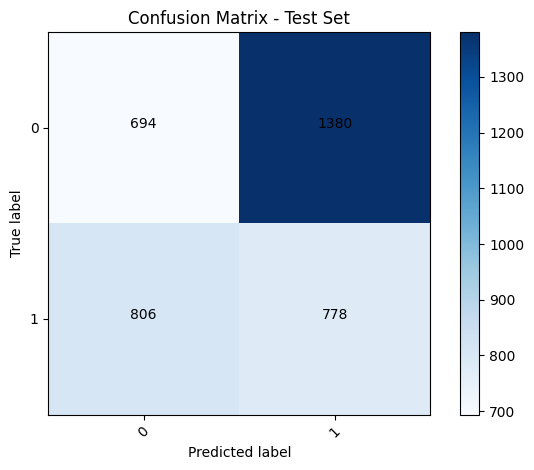

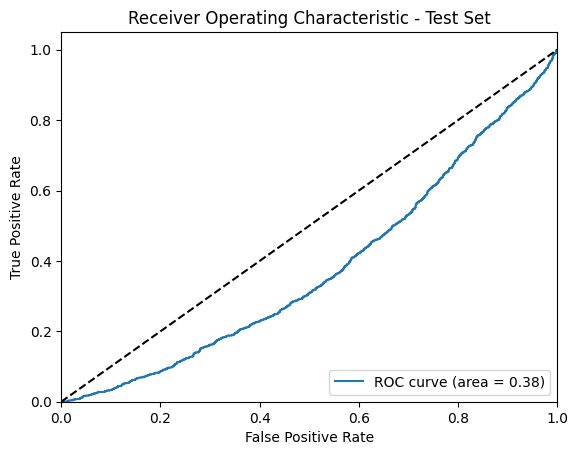

ROC AUC score: 0.38

Test f1 score:  0.40209039870769264
              precision    recall  f1-score   support

           0       0.46      0.33      0.39      2074
           1       0.36      0.49      0.42      1584

    accuracy                           0.40      3658
   macro avg       0.41      0.41      0.40      3658
weighted avg       0.42      0.40      0.40      3658
 




In [25]:
# MODEL TEST
model = joblib.load("bayesianOptResult.pkl")
prettyPrint(model, "CD4 PBMC", x_resampled, y_resampled, x_test, y_test, x_val, y_val, True)

In [4]:
# Refittiamo il modello su tutto il dataset
model = joblib.load("bayesianOptResult.pkl")
print("Best Parameters: \n{}\n".format(model.best_params_))

AttributeError: Can't get attribute 'precision_class_0' on <module '__main__'>

In [ ]:
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

# Define the best parameters found by BayesSearchCV
best_params = {
    'gamma': 1e-06,
    'learning_rate': 4.222975850408766,
    'max_depth': 2,
    'min_child_weight': 1,
    'n_estimators': 1357,
    'reg_alpha': 1e-06,
    'reg_lambda': 1e-06,
    'scale_pos_weight': 0.41007194244604317
}

# Create XGBoost classifier with the best parameters
xgb_classifier = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    seed=42,
    tree_method='hist',  # Add tree_method for GPU support
    device="cuda",
    **best_params  # Pass best_params directly
)

# Create a pipeline with MinMaxScaler and XGBoost
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),  # MinMaxScaler
    ('classifier', xgb_classifier)  # XGBoost classifier
])

# Fit the pipeline on the resampled training data
pipeline.fit(x_resampled, y_resampled)

print("Fitted pipeline on the resampled training data.")

# Make predictions on the validation set
y_pred_val = pipeline.predict(x_val)

# Evaluate predictions on the validation set
accuracy = accuracy_score(y_val, y_pred_val)
precision = precision_score(y_val, y_pred_val)
recall = recall_score(y_val, y_pred_val)
f1 = f1_score(y_val, y_pred_val)
roc_auc = roc_auc_score(y_val, pipeline.predict_proba(x_val)[:, 1])
confusion = confusion_matrix(y_val, y_pred_val)

print("\n--- Evaluation Metrics on Validation Set ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(confusion)


In [ ]:
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

best_params = {
    'gamma': 1e-06,
    'learning_rate': 4.222975850408766,
    'max_depth': 2,
    'min_child_weight': 1,
    'n_estimators': 1357,
    'reg_alpha': 1e-06,
    'reg_lambda': 1e-06,
    'scale_pos_weight': 0.41007194244604317
}
# Create XGBoost classifier with the best parameters
xgb_classifier = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    seed=42,
    tree_method='hist',  # Add tree_method for GPU support
    device="cuda",
    **best_params  # Pass best_params directly
)

# Create a pipeline with MinMaxScaler and XGBoost
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),  # MinMaxScaler
    ('classifier', xgb_classifier)  # XGBoost classifier
])

# Combine the training and validation data
X_full = pd.concat([x_train, x_val], axis=0)
y_full = pd.concat([y_train, y_val], axis=0)

# Fit the pipeline on the full dataset
pipeline.fit(X_full, y_full)

print("Fitted pipeline on the combined training and validation data.")

# Make predictions on the test set
y_pred_test = pipeline.predict(x_test)

# Evaluate predictions on the test set
accuracy = accuracy_score(y_test, y_pred_test)
precision = precision_score(y_test, y_pred_test)
recall = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
roc_auc = roc_auc_score(y_test, pipeline.predict_proba(x_test)[:, 1])
confusion = confusion_matrix(y_test, y_pred_test)

print("\n--- Evaluation Metrics on Test Set ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(confusion)


In [ ]:
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

# Define the best parameters found by BayesSearchCV
best_params = {
    'gamma': 1.3532563214860596e-06,
    'learning_rate': 1e-07,
    'max_depth': 15,
    'min_child_weight': 3,
    'n_estimators': 50,
    'reg_alpha': 9.374725233161003e-06,
    'reg_lambda': 8.8377155785197e-05,
    'scale_pos_weight': 1,
}

# Create XGBoost classifier with the best parameters
xgb_classifier = xgb.XGBClassifier(
    objective='binary:logistic',
    use_label_encoder=False,
    eval_metric='logloss',
    seed=42,
    tree_method='hist',  # Add tree_method for GPU support
    device="cuda",
    **best_params  # Pass best_params directly
)

# Create a pipeline with MinMaxScaler and XGBoost
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),  # MinMaxScaler
    ('classifier', xgb_classifier)  # XGBoost classifier
])

# Combine the training and validation data
X_full = pd.concat([x_train, x_val, x_test], axis=0)
y_full = pd.concat([y_train, y_val, y_test], axis=0)

# Fit the pipeline on the full dataset
pipeline.fit(X_full, y_full)

print("Fitted pipeline on the combined training, validation data and test data.")

#inutile fare predizioni qui

#salviamo
joblib.dump(pipeline, "BestModelRefittedWholeDataset.pkl")
